In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

In [55]:
df = pd.read_csv('m1-demo-data.csv', encoding='latin1')

In [56]:
print("--- TOP 5 ROWS ---")
print(df.head(5))

print("\n--- BOTTOM 5 ROWS ---")
print(df.tail(5))

--- TOP 5 ROWS ---
         NIM             Nama   IPK  Kehadiran_Persen  Tugas_Persen  \
0  2022IF001  Irwan Mahardika  3.29              88.0          90.0   
1  2022IF002              NaN  2.71              56.0          30.0   
2  2022IF003    Qisya Wardani  3.59              94.0          70.0   
3  2022IF004   Cahya Pasaribu  2.32              50.0          30.0   
4  2022IF005     Hadi Maulana  3.22              75.0          70.0   

        Status  
0        Lulus  
1  Tidak Lulus  
2        Lulus  
3  Tidak Lulus  
4        Lulus  

--- BOTTOM 5 ROWS ---
           NIM     Nama   IPK  Kehadiran_Persen  Tugas_Persen       Status
245  2022IF246  Nama246  3.04              91.0           NaN        Lulus
246  2022IF247  Nama247  3.50              76.0          62.0        Lulus
247  2022IF248  Nama248  3.17              82.0          57.0  Tidak Lulus
248  2022IF249  Nama249  3.21              94.0          73.0        Lulus
249  2022IF250  Nama250  3.78              86.0       

In [57]:
print("\n--- STATISTICAL SUMMARY ---")
summary = df.describe().T
summary['median'] = df.median(numeric_only=True)
print(summary[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']])


--- STATISTICAL SUMMARY ---
                       mean  median        std    min    25%    50%    75%  \
IPK                2.918903    3.04   0.526897   1.44   2.68   3.04   3.26   
Kehadiran_Persen  79.032653   81.00  15.863886  31.00  75.00  81.00  91.00   
Tugas_Persen      70.225532   71.00  21.867027   0.00  63.00  71.00  80.00   

                    max  
IPK                 4.0  
Kehadiran_Persen  100.0  
Tugas_Persen      100.0  


In [58]:
print("--- Jumlah Data Null Per Kolom ---")
print(df.isnull().sum())

print("\n--- Persentase Data Null Per Kolom ---")
print((df.isnull().sum() / len(df)) * 100)

print("\nTotal seluruh data null:", df.isnull().sum().sum())

print("Apakah ada data null?:", df.isnull().values.any())

df.info()

--- Jumlah Data Null Per Kolom ---
NIM                  0
Nama                15
IPK                 13
Kehadiran_Persen     5
Tugas_Persen        15
Status               0
dtype: int64

--- Persentase Data Null Per Kolom ---
NIM                 0.0
Nama                6.0
IPK                 5.2
Kehadiran_Persen    2.0
Tugas_Persen        6.0
Status              0.0
dtype: float64

Total seluruh data null: 48
Apakah ada data null?: True
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   NIM               250 non-null    str    
 1   Nama              235 non-null    str    
 2   IPK               237 non-null    float64
 3   Kehadiran_Persen  245 non-null    float64
 4   Tugas_Persen      235 non-null    float64
 5   Status            250 non-null    str    
dtypes: float64(3), str(3)
memory usage: 18.4 KB


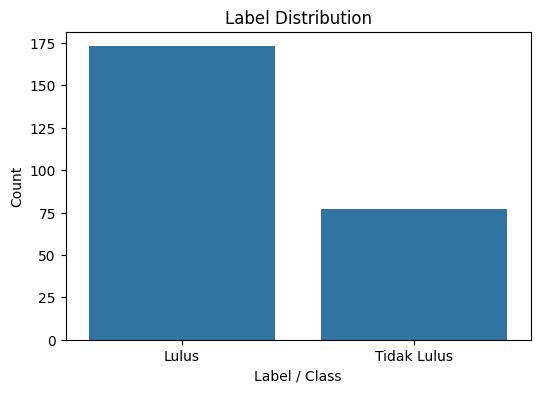

In [59]:
plt.figure(figsize=(6, 4))
label_col = 'Status' if 'Status' in df.columns else df.columns[-1] 
sns.countplot(data=df, x=label_col)
plt.title('Label Distribution')
plt.xlabel('Label / Class')
plt.ylabel('Count')
plt.show()

In [60]:
# a. Fill empty values in 'IPK' and 'Kehadiran_Persen' with mean
df['IPK'] = df['IPK'].fillna(df['IPK'].mean())
df['Kehadiran_Persen'] = df['Kehadiran_Persen'].fillna(df['Kehadiran_Persen'].mean())

# b. Fill empty values in 'Tugas_Persen' with median
df['Tugas_Persen'] = df['Tugas_Persen'].fillna(df['Tugas_Persen'].median())

# c. Fill empty values in 'Nama' with 'Nama_Tidak_Diketahui'
df['Nama'] = df['Nama'].fillna('Nama_Tidak_Diketahui')

In [61]:
print("--- Jumlah Data Null Per Kolom ---")
print(df.isnull().sum())

print("\n--- Persentase Data Null Per Kolom ---")
print((df.isnull().sum() / len(df)) * 100)

print("\nTotal seluruh data null:", df.isnull().sum().sum())

print("Apakah ada data null?:", df.isnull().values.any())

df.info()

--- Jumlah Data Null Per Kolom ---
NIM                 0
Nama                0
IPK                 0
Kehadiran_Persen    0
Tugas_Persen        0
Status              0
dtype: int64

--- Persentase Data Null Per Kolom ---
NIM                 0.0
Nama                0.0
IPK                 0.0
Kehadiran_Persen    0.0
Tugas_Persen        0.0
Status              0.0
dtype: float64

Total seluruh data null: 0
Apakah ada data null?: False
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   NIM               250 non-null    str    
 1   Nama              250 non-null    str    
 2   IPK               250 non-null    float64
 3   Kehadiran_Persen  250 non-null    float64
 4   Tugas_Persen      250 non-null    float64
 5   Status            250 non-null    str    
dtypes: float64(3), str(3)
memory usage: 18.7 KB


In [62]:
feature_cols = ['IPK', 'Kehadiran_Persen', 'Tugas_Persen']
X = df[feature_cols]
y = df[label_col]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [65]:
y_pred = model.predict(X_test)

In [66]:
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Lulus       0.89      1.00      0.94        33
 Tidak Lulus       1.00      0.76      0.87        17

    accuracy                           0.92        50
   macro avg       0.95      0.88      0.90        50
weighted avg       0.93      0.92      0.92        50

Model Accuracy: 92.00%


In [67]:
new_data = pd.DataFrame([
    {'IPK': 3.2, 'Kehadiran_Persen': 85, 'Tugas_Persen': 20}, # a
    {'IPK': 2.1, 'Kehadiran_Persen': 60, 'Tugas_Persen': 50}, # b
    {'IPK': 3.8, 'Kehadiran_Persen': 95, 'Tugas_Persen': 90}  # c
])

predictions = model.predict(new_data)

print("\n--- NEW DATA PREDICTIONS ---")
for i, pred in enumerate(predictions):
    case = ['a', 'b', 'c'][i]
    print(f"Case {case}: {dict(new_data.iloc[i])} --> Prediction: {pred}")


--- NEW DATA PREDICTIONS ---
Case a: {'IPK': np.float64(3.2), 'Kehadiran_Persen': np.float64(85.0), 'Tugas_Persen': np.float64(20.0)} --> Prediction: Tidak Lulus
Case b: {'IPK': np.float64(2.1), 'Kehadiran_Persen': np.float64(60.0), 'Tugas_Persen': np.float64(50.0)} --> Prediction: Tidak Lulus
Case c: {'IPK': np.float64(3.8), 'Kehadiran_Persen': np.float64(95.0), 'Tugas_Persen': np.float64(90.0)} --> Prediction: Lulus
